<a href="https://colab.research.google.com/github/ankitkumar2023/Part-1-Data-Audit-EDA-Business-Understanding/blob/main/Data_Audit%2C_EDA_%26_Business_Understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Import Libraries and Mount Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/d2c churn data package/"

try:
    files = os.listdir(BASE_PATH)
    print("Success! Colab sees the folder. Here are the files inside:")
    for file in files:
        print(f"- {file}")
except FileNotFoundError:
    print("Error: Colab STILL cannot find the folder. The sync might need another minute.")

Success! Colab sees the folder. Here are the files inside:
- web_events_snapshot.csv
- churn_labels.csv
- rfm_modeling_snapshot.csv
- support_tickets.csv
- customers.csv
- orders.csv
- intervention_history.csv
- STUDENT_FACING_PROBLEM_STATEMENT.md
- DATA_DICTIONARY.md


**Section 2: Import Required Python Packages**

These libraries provide capabilities for loading datasets, performing analysis, creating charts, and detecting anomalies.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")

**Section 3: Load All Raw Datasets**

In [ ]:
customers = pd.read_csv(
    BASE_PATH + "customers.csv",
    parse_dates=["signup_date"]
)

orders = pd.read_csv(
    BASE_PATH + "orders.csv",
    parse_dates=["order_date"]
)

tickets = pd.read_csv(
    BASE_PATH + "support_tickets.csv",
    parse_dates=["ticket_date"]
)

web_events = pd.read_csv(
    BASE_PATH + "web_events_snapshot.csv",
    parse_dates=["snapshot_date"]
)

churn = pd.read_csv(
    BASE_PATH + "churn_labels.csv",
    parse_dates=["snapshot_date"]
)

interventions = pd.read_csv(
    BASE_PATH + "intervention_history.csv",
    parse_dates=["snapshot_date"]
)

**Section 4: Verify Dataset Dimensions**

In [ ]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Support Tickets": tickets,
    "Web Events": web_events,
    "Churn Labels": churn,
    "Interventions": interventions
}


for name, df in datasets.items():
    print("=" * 50)
    print(f"{name} Dataset")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])

Customers Dataset
Rows: 2400
Columns: 9
Orders Dataset
Rows: 10009
Columns: 10
Support Tickets Dataset
Rows: 1921
Columns: 8
Web Events Dataset
Rows: 2400
Columns: 10
Churn Labels Dataset
Rows: 2400
Columns: 4
Interventions Dataset
Rows: 2400
Columns: 5


# Section 5: Inspect Data Schema and Data
Schema inspection identifies incorrect datatypes, unexpected columns, and potential preprocessing requirements before analysis.

In [ ]:
for name, df in datasets.items():
    print("\n" + "=" * 70)
    print(f"{name} Schema Information")

    print(df.info())

    print("\nSample Records:")
    display(df.head())


Customers Schema Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          2400 non-null   object        
 1   signup_date          2400 non-null   datetime64[ns]
 2   city_tier            2400 non-null   object        
 3   age_group            2400 non-null   object        
 4   acquisition_channel  2400 non-null   object        
 5   loyalty_tier         1014 non-null   object        
 6   preferred_category   2400 non-null   object        
 7   skin_type            1999 non-null   object        
 8   marketing_consent    2400 non-null   object        
dtypes: datetime64[ns](1), object(8)
memory usage: 168.9+ KB
None

Sample Records:


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes



Orders Schema Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       10009 non-null  object        
 1   customer_id    10009 non-null  object        
 2   order_date     10009 non-null  datetime64[ns]
 3   category       10009 non-null  object        
 4   quantity       10009 non-null  int64         
 5   gross_amount   10009 non-null  float64       
 6   discount_pct   10009 non-null  float64       
 7   delivery_days  10009 non-null  int64         
 8   returned       10009 non-null  int64         
 9   rating         9929 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(3), object(3)
memory usage: 782.1+ KB
None

Sample Records:


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0



Support Tickets Schema Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1921 entries, 0 to 1920
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ticket_id         1921 non-null   object        
 1   customer_id       1921 non-null   object        
 2   ticket_date       1921 non-null   datetime64[ns]
 3   issue_type        1921 non-null   object        
 4   support_channel   1921 non-null   object        
 5   resolution_hours  1921 non-null   float64       
 6   sentiment_score   1921 non-null   float64       
 7   reopened          1921 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 120.2+ KB
None

Sample Records:


...

,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26
3,CUST00004,2025-09-30,1,6,0,0,0,0,0,14
4,CUST00005,2025-09-30,18,95,4,1,1,3,1,9



Churn Labels Schema Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_id     2400 non-null   object        
 1   snapshot_date   2400 non-null   datetime64[ns]
 2   churn_next_60d  2400 non-null   int64         
 3   split           2400 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 75.1+ KB
None

Sample Records:


,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train
3,CUST00004,2025-09-30,1,train
4,CUST00005,2025-09-30,0,train



Interventions Schema Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   customer_id             2400 non-null   object        
 1   snapshot_date           2400 non-null   datetime64[ns]
 2   last_campaign_received  2400 non-null   object        
 3   last_campaign_cost      2400 non-null   int64         
 4   manual_priority_bucket  2400 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 93.9+ KB
None

Sample Records:


,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,18,high
3,CUST00004,2025-09-30,free_shipping,40,high
4,CUST00005,2025-09-30,welcome_offer,18,medium


# Section 6: Create Automated Data Quality Summary Function

Automated auditing ensures consistent identification of missing values, duplicates, unique counts, and datatype issues.

In [ ]:
def data_quality_report(df, dataset_name):

    report = pd.DataFrame({
        "column": df.columns,
        "data_type": df.dtypes.values,
        "missing_count": df.isnull().sum().values,
        "missing_percentage": (
            df.isnull().mean() * 100
        ).round(2).values,
        "unique_values": df.nunique().values
    })

    print("\n" + "="*80)
    print(f"DATA QUALITY REPORT: {dataset_name}")
    display(report)

    print(
        f"Total duplicate rows: {df.duplicated().sum()}"
    )

# Section 7: Run Quality Audit Across Every Dataset

Running automated audits provides a complete overview of quality concerns across all source systems.

In [ ]:
for name, df in datasets.items():
    data_quality_report(df, name)


DATA QUALITY REPORT: Customers


,column,data_type,missing_count,missing_percentage,unique_values
0,customer_id,object,0,0.00,2400
1,signup_date,datetime64[ns],0,0.00,609
2,city_tier,object,0,0.00,3
3,age_group,object,0,0.00,4
4,acquisition_channel,object,0,0.00,6
5,loyalty_tier,object,1386,57.75,3
6,preferred_category,object,0,0.00,6
7,skin_type,object,401,16.71,5
8,marketing_consent,object,0,0.00,2


Total duplicate rows: 0

DATA QUALITY REPORT: Orders


,column,data_type,missing_count,missing_percentage,unique_values
0,order_id,object,0,0.0,10009
1,customer_id,object,0,0.0,2400
2,order_date,datetime64[ns],0,0.0,674
3,category,object,0,0.0,6
4,quantity,int64,0,0.0,4
5,gross_amount,float64,0,0.0,9514
6,discount_pct,float64,0,0.0,71
7,delivery_days,int64,0,0.0,11
8,returned,int64,0,0.0,2
9,rating,float64,80,0.8,5


Total duplicate rows: 0

DATA QUALITY REPORT: Support Tickets


...

Total duplicate rows: 0

DATA QUALITY REPORT: Churn Labels


,column,data_type,missing_count,missing_percentage,unique_values
0,customer_id,object,0,0.0,2400
1,snapshot_date,datetime64[ns],0,0.0,1
2,churn_next_60d,int64,0,0.0,2
3,split,object,0,0.0,3


Total duplicate rows: 0

DATA QUALITY REPORT: Interventions


,column,data_type,missing_count,missing_percentage,unique_values
0,customer_id,object,0,0.0,2400
1,snapshot_date,datetime64[ns],0,0.0,1
2,last_campaign_received,object,0,0.0,5
3,last_campaign_cost,int64,0,0.0,5
4,manual_priority_bucket,object,0,0.0,3


Total duplicate rows: 0


# Section 8: Identify Missing Values Specifically
Missing information impacts customer profiling, segmentation, and future predictive model feature reliability.

In [ ]:
for name, df in datasets.items():

    missing = (
        df.isnull()
        .sum()
        .sort_values(ascending=False)
    )

    missing = missing[missing > 0]

    if len(missing) > 0:

        print("\n" + "="*60)
        print(name)

        print(missing)


Customers
loyalty_tier    1386
skin_type        401
dtype: int64

Orders
rating    80
dtype: int64


# Section 9: Detect Duplicate-Like Order Records

Orders containing duplicate suffixes represent intentional quality problems requiring business investigation and handling.

In [ ]:
duplicate_orders = orders[
    orders["order_id"].str.contains("_DUP")
]

print(
    "Duplicate-like orders found:",
    duplicate_orders.shape[0]
)

display(
    duplicate_orders.head(10)
)

Duplicate-like orders found: 12


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
601,ORD008249_DUP,CUST00153,2025-11-04,Hair Care,1,321.31,0.36,8,0,3.0
2621,ORD002124_DUP,CUST00628,2025-03-18,Skin Care,1,410.04,0.47,3,0,5.0
3534,ORD002862_DUP,CUST00837,2025-07-12,Hair Care,3,952.02,0.47,4,0,4.0
3602,ORD002916_DUP,CUST00848,2025-09-26,Skin Care,1,547.18,0.28,2,0,5.0
3675,ORD002970_DUP,CUST00869,2024-12-22,Fragrance,1,818.64,0.18,2,0,4.0
3708,ORD008836_DUP,CUST00875,2025-10-23,Baby Care,2,711.20,0.19,6,0,5.0
4799,ORD003897_DUP,CUST01140,2025-04-14,Baby Care,2,769.96,0.25,5,0,4.0
5633,ORD004577_DUP,CUST01335,2025-02-12,Wellness,1,533.07,0.28,3,0,3.0
6687,ORD005451_DUP,CUST01601,2024-11-07,Makeup,2,1160.41,0.32,4,0,5.0
6780,ORD005529_DUP,CUST01621,2024-08-12,Baby Care,1,339.33,0.15,3,0,1.0


# Section 10: Prevent Data Leakage Using Snapshot Date

In [ ]:
SNAPSHOT_DATE = pd.Timestamp("2025-09-30")


orders_before_snapshot = (
    orders[
        orders["order_date"] <= SNAPSHOT_DATE
    ]
    .copy()
)


orders_after_snapshot = (
    orders[
        orders["order_date"] > SNAPSHOT_DATE
    ]
    .copy()
)


print(
    "Orders allowed for analysis:",
    orders_before_snapshot.shape[0]
)

print(
    "Post-snapshot orders excluded:",
    orders_after_snapshot.shape[0]
)

Orders allowed for analysis: 8137
Post-snapshot orders excluded: 1872


# Section 11: Check Date Consistency Across Tables

Date validation detects impossible timelines and confirms records align with defined snapshot boundaries.

In [ ]:
date_columns = {
    "Customers": customers["signup_date"],
    "Orders": orders["order_date"],
    "Tickets": tickets["ticket_date"],
    "Web Events": web_events["snapshot_date"],
    "Churn Labels": churn["snapshot_date"],
    "Interventions": interventions["snapshot_date"]
}


for name, column in date_columns.items():

    print("\n" + "="*50)
    print(name)

    print(
        "Minimum Date:",
        column.min()
    )

    print(
        "Maximum Date:",
        column.max()
    )


Customers
Minimum Date: 2024-01-01 00:00:00
Maximum Date: 2025-09-15 00:00:00

Orders
Minimum Date: 2024-01-09 00:00:00
Maximum Date: 2025-11-29 00:00:00

Tickets
Minimum Date: 2024-01-13 00:00:00
Maximum Date: 2025-09-30 00:00:00

Web Events
Minimum Date: 2025-09-30 00:00:00
Maximum Date: 2025-09-30 00:00:00

Churn Labels
Minimum Date: 2025-09-30 00:00:00
Maximum Date: 2025-09-30 00:00:00

Interventions
Minimum Date: 2025-09-30 00:00:00
Maximum Date: 2025-09-30 00:00:00


# Section 12: Detect Invalid Numerical Values

Business rule validation identifies impossible amounts, percentages, delivery durations, and customer ratings.

In [ ]:
invalid_orders = orders_before_snapshot[
    (
        orders_before_snapshot["gross_amount"] < 0
    )
    |
    (
        orders_before_snapshot["discount_pct"] < 0
    )
    |
    (
        orders_before_snapshot["discount_pct"] > 1
    )
    |
    (
        orders_before_snapshot["delivery_days"] < 0
    )
]


print(
    "Invalid order records:",
    invalid_orders.shape[0]
)

Invalid order records: 0


# Section 13: Detect Monetary Outliers Using IQR Method

Extreme order values can distort spending analysis and require careful business interpretation.

In [ ]:
Q1 = orders_before_snapshot["gross_amount"].quantile(0.25)

Q3 = orders_before_snapshot["gross_amount"].quantile(0.75)

IQR = Q3 - Q1


lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR


amount_outliers = orders_before_snapshot[
    (
        orders_before_snapshot["gross_amount"] < lower_limit
    )
    |
    (
        orders_before_snapshot["gross_amount"] > upper_limit
    )
]


print(
    "Number of monetary outliers:",
    amount_outliers.shape[0]
)

display(
    amount_outliers[
        [
            "customer_id",
            "order_id",
            "gross_amount"
        ]
    ].head(10)
)

Number of monetary outliers: 429


,customer_id,order_id,gross_amount
45,CUST00014,ORD000034,1781.74
73,CUST00020,ORD000055,2710.51
84,CUST00025,ORD000067,1987.35
93,CUST00027,ORD000073,2128.34
159,CUST00042,ORD000130,1908.63
191,CUST00051,ORD000150,2302.34
196,CUST00053,ORD000155,2128.72
214,CUST00057,ORD000167,1713.34
240,CUST00065,ORD000187,1911.67
248,CUST00066,ORD000188,2447.60


# Section 14: Validate Join Keys Between Business Tables

Join validation ensures customer records connect correctly without accidental data loss during analysis.

In [ ]:
tables = [
    orders_before_snapshot,
    tickets,
    web_events,
    churn,
    interventions
]


names = [
    "Orders",
    "Tickets",
    "Web Events",
    "Churn Labels",
    "Interventions"
]


for name, table in zip(names, tables):

    missing_customers = (
        ~table["customer_id"]
        .isin(customers["customer_id"])
    ).sum()

    print(
        f"{name} unmatched customers:",
        missing_customers
    )

Orders unmatched customers: 0
Tickets unmatched customers: 0
Web Events unmatched customers: 0
Churn Labels unmatched customers: 0
Interventions unmatched customers: 0


# Section 15: Create Safe Customer-Level Analytical Dataset



*   Customer-level aggregation prevents duplicate customer rows and enables accurate churn comparison across behavioral dimensions.
* Only pre-snapshot orders are aggregated ensuring future purchase information never leaks into customer analysis.



In [ ]:
order_summary = (
    orders_before_snapshot
    .groupby("customer_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_spend=("gross_amount", "sum"),
        average_order_value=("gross_amount", "mean"),
        average_discount=("discount_pct", "mean"),
        total_returns=("returned", "sum"),
        average_rating=("rating", "mean"),
        average_delivery_days=("delivery_days", "mean"),
        categories_purchased=("category", "nunique")
    )
    .reset_index()
)

display(order_summary.head())

,customer_id,total_orders,total_spend,average_order_value,average_discount,total_returns,average_rating,average_delivery_days,categories_purchased
0,CUST00001,6,2955.57,492.5950,0.363333,1,3.333333,3.50,3
1,CUST00002,1,581.00,581.0000,0.230000,0,4.000000,5.00,1
2,CUST00003,1,649.98,649.9800,0.470000,0,2.000000,2.00,1
3,CUST00004,1,1604.04,1604.0400,0.160000,0,2.000000,5.00,1
4,CUST00005,4,2550.91,637.7275,0.442500,0,2.000000,5.75,2


# Section 16: Aggregate Customer Support Behavior

Support interactions reveal dissatisfaction signals that may influence future customer churn decisions significantly.

In [ ]:
ticket_summary = (
    tickets
    .groupby("customer_id")
    .agg(
        total_tickets=("ticket_id", "count"),
        average_resolution_time=("resolution_hours", "mean"),
        average_sentiment=("sentiment_score", "mean"),
        reopened_tickets=("reopened", "sum")
    )
    .reset_index()
)

display(ticket_summary.head())

,customer_id,total_tickets,average_resolution_time,average_sentiment,reopened_tickets
0,CUST00001,2,4.35,0.14,0
1,CUST00002,1,1.00,0.00,0
2,CUST00005,1,37.70,-1.00,0
3,CUST00006,2,17.60,-0.68,1
4,CUST00008,1,6.00,0.08,0


# Section 17: Join All Customer Information Using Left Join Strategy

Left joins preserve complete customer universe including users without orders or support interactions.

In [ ]:
customer_analysis = customers.copy()

customer_analysis = customer_analysis.merge(
    order_summary,
    on="customer_id",
    how="left"
)

customer_analysis = customer_analysis.merge(
    ticket_summary,
    on="customer_id",
    how="left"
)

customer_analysis = customer_analysis.merge(
    web_events,
    on="customer_id",
    how="left"
)

customer_analysis = customer_analysis.merge(
    interventions,
    on="customer_id",
    how="left",
    suffixes=("", "_campaign")
)

customer_analysis = customer_analysis.merge(
    churn,
    on="customer_id",
    how="left",
    suffixes=("", "_label")
)

print("Final customer dataset shape:")
print(customer_analysis.shape)

Final customer dataset shape:
(2400, 37)


# Section 18: Handle Missing Values Created After Aggregations

Missing behavioral values generally represent no activity and should receive business-aware defaults.

In [ ]:
fill_zero_columns = [
    "total_orders",
    "total_spend",
    "average_order_value",
    "average_discount",
    "total_returns",
    "total_tickets",
    "average_resolution_time",
    "average_sentiment",
    "reopened_tickets",
    "sessions_30d",
    "product_views_30d",
    "cart_adds_30d",
    "wishlist_adds_30d",
    "abandoned_carts_30d",
    "email_opens_30d",
    "campaign_clicks_30d"
]

customer_analysis[fill_zero_columns] = (
    customer_analysis[fill_zero_columns]
    .fillna(0)
)

# Section 19: Create Churn Distribution Table

Understanding churn balance helps determine customer risk magnitude and future retention priorities.

In [ ]:
churn_distribution = (
    customer_analysis["churn_next_60d"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("percentage")
)

display(churn_distribution)

,percentage
churn_next_60d,
0,53.04
1,46.96


**Chart 1: Overall Churn Distribution**

This visualization highlights overall customer retention and churn proportions within the business.

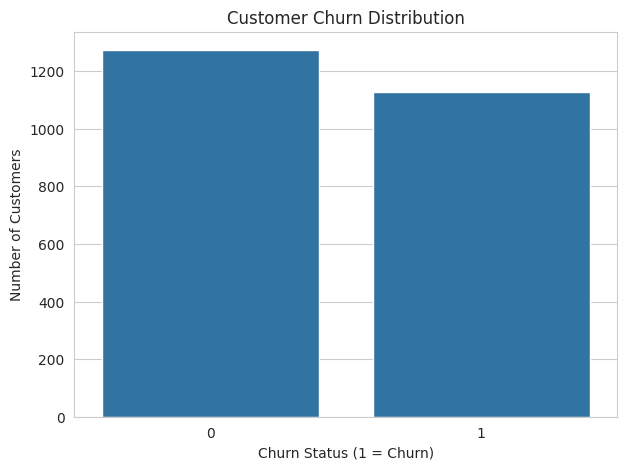

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=customer_analysis,
    x="churn_next_60d"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status (1 = Churn)")
plt.ylabel("Number of Customers")

plt.show()

**Chart 2: Churn Rate by City Tier**

Geographic market categories may show different customer engagement and retention behavior patterns.

,churn_next_60d
city_tier,
Tier 2,47.701149
Tier 1,47.363184
Tier 3,44.952381


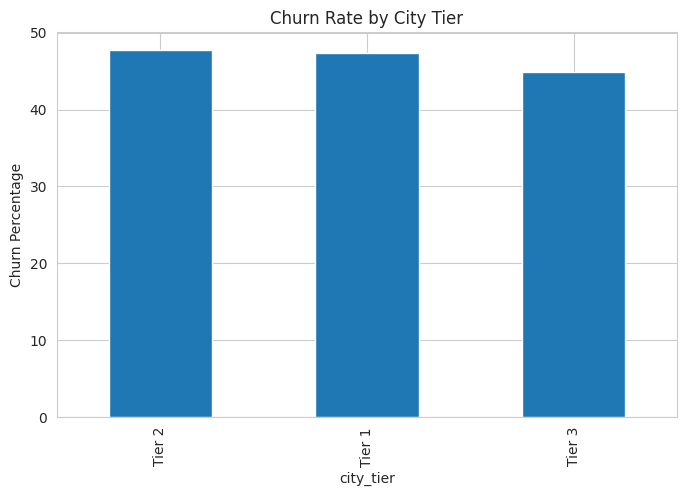

In [ ]:
city_churn = (
    customer_analysis
    .groupby("city_tier")["churn_next_60d"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

display(city_churn)

plt.figure(figsize=(8,5))

city_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Percentage")
plt.title("Churn Rate by City Tier")

plt.show()

**Chart 3: Customer Acquisition Channel vs Churn**

Marketing channels can attract customers with different lifetime value and loyalty characteristics.

,churn_next_60d
acquisition_channel,
Google Search,50.429185
Instagram,49.903288
Marketplace,49.122807
Influencer,47.619048
Referral,42.171717
Organic,39.820359


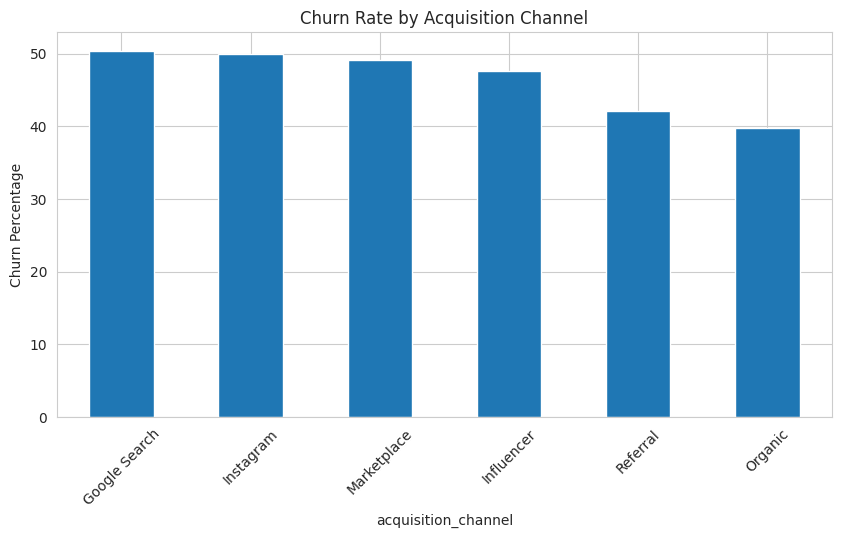

In [ ]:
acquisition_churn = (
    customer_analysis
    .groupby("acquisition_channel")["churn_next_60d"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

display(acquisition_churn)

plt.figure(figsize=(10,5))

acquisition_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Percentage")
plt.title("Churn Rate by Acquisition Channel")

plt.xticks(rotation=45)

plt.show()

**Chart 4: Loyalty Tier Relationship with Churn**

Loyalty enrollment effectiveness can be evaluated by comparing churn across membership groups.

,churn_next_60d
loyalty_tier,
Silver,48.813559
Gold,40.752351
Platinum,37.142857


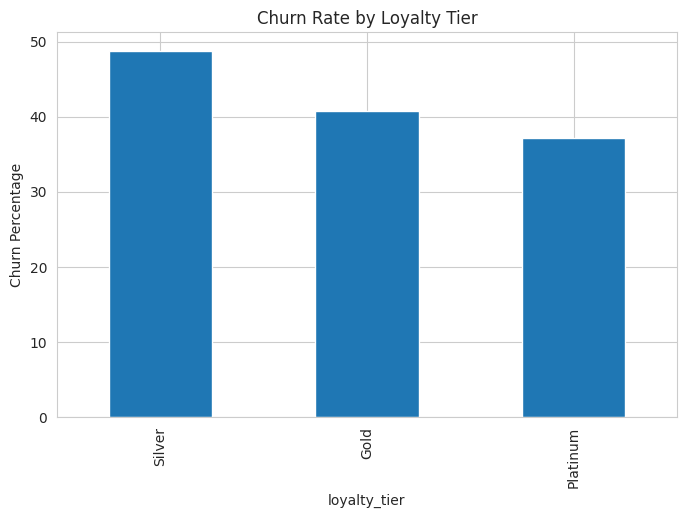

In [ ]:
loyalty_churn = (
    customer_analysis
    .groupby("loyalty_tier")["churn_next_60d"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

display(loyalty_churn)

plt.figure(figsize=(8,5))

loyalty_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Percentage")
plt.title("Churn Rate by Loyalty Tier")

plt.show()

**Chart 5: Spending Behavior Between Churned and Retained Customers**

Monetary differences reveal whether low-value customers demonstrate stronger probability of leaving.

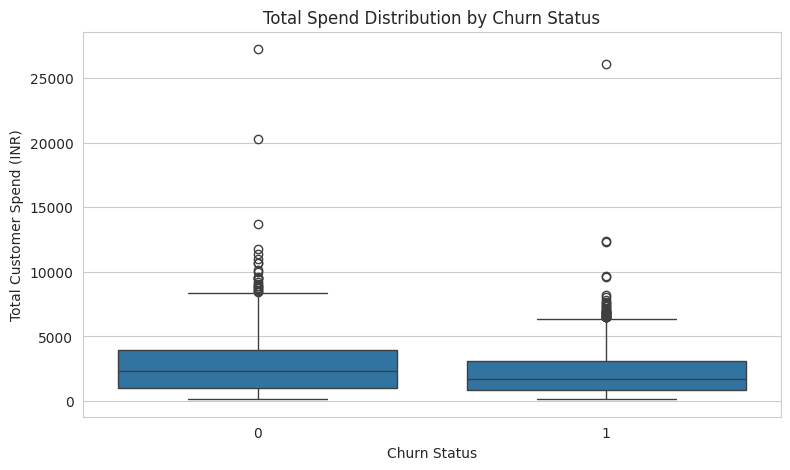

In [ ]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=customer_analysis,
    x="churn_next_60d",
    y="total_spend"
)

plt.title(
    "Total Spend Distribution by Churn Status"
)

plt.xlabel("Churn Status")
plt.ylabel("Total Customer Spend (INR)")

plt.show()

**Chart 6: Customer Order Frequency and Churn Relationship**

Purchase frequency provides strong evidence regarding engagement and future retention likelihood.

,count,mean,std,min,25%,50%,75%,max
churn_next_60d,,,,,,,,
0,1273.0,3.704635,2.554276,1.0,1.0,3.0,5.0,16.0
1,1127.0,3.035492,2.119976,1.0,1.0,2.0,4.0,12.0


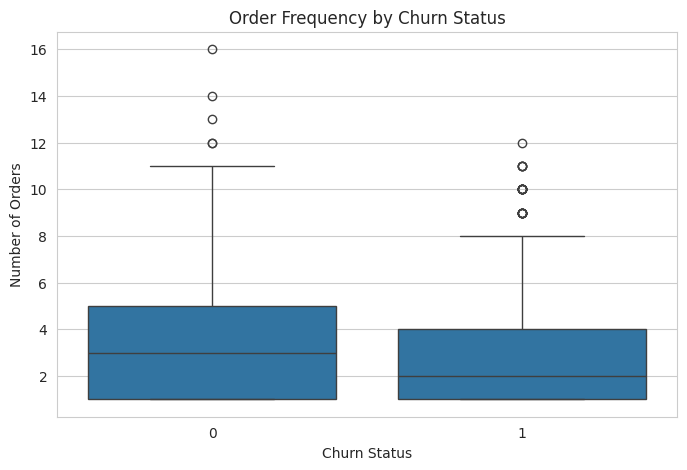

In [ ]:
order_frequency = (
    customer_analysis
    .groupby("churn_next_60d")["total_orders"]
    .describe()
)

display(order_frequency)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=customer_analysis,
    x="churn_next_60d",
    y="total_orders"
)

plt.title(
    "Order Frequency by Churn Status"
)

plt.xlabel("Churn Status")
plt.ylabel("Number of Orders")

plt.show()

**Chart 7: Web Activity Relationship with Churn**

Recent website engagement indicates customer interest and possible future purchasing intentions.

,sessions_30d,product_views_30d,cart_adds_30d,campaign_clicks_30d
churn_next_60d,,,,
0,6.732129,28.375491,1.945797,0.736057
1,4.023070,16.974268,1.125998,0.551908


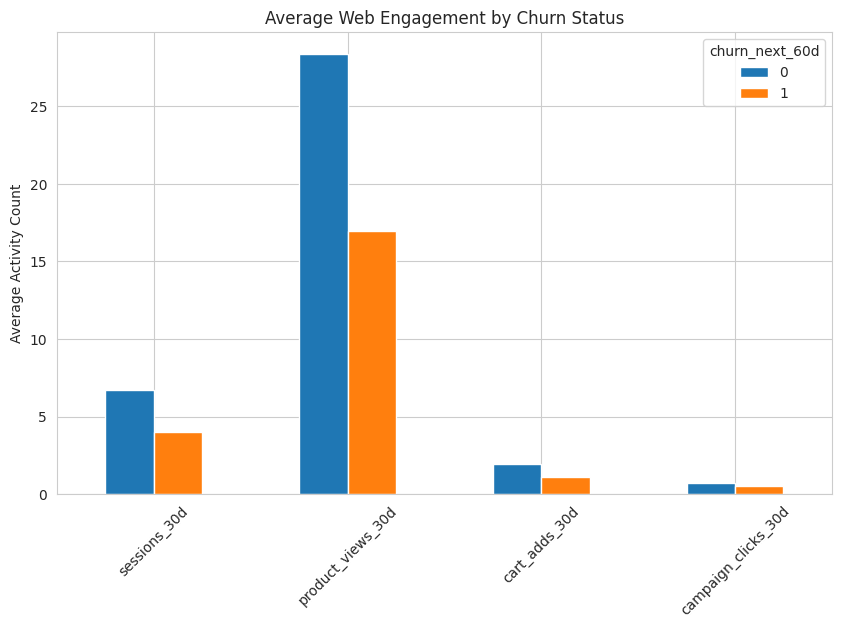

In [ ]:
web_activity = (
    customer_analysis
    .groupby("churn_next_60d")[
        [
            "sessions_30d",
            "product_views_30d",
            "cart_adds_30d",
            "campaign_clicks_30d"
        ]
    ]
    .mean()
)

display(web_activity)

web_activity.T.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Average Web Engagement by Churn Status"
)

plt.ylabel("Average Activity Count")

plt.xticks(rotation=45)

plt.show()

**Chart 8: Support Ticket Volume and Churn Relationship**


Frequent customer complaints may indicate dissatisfaction and increase probability of future customer attrition.

,total_tickets,average_resolution_time,reopened_tickets
churn_next_60d,,,
0,0.852317,12.861436,0.155538
1,0.741792,12.594101,0.125998


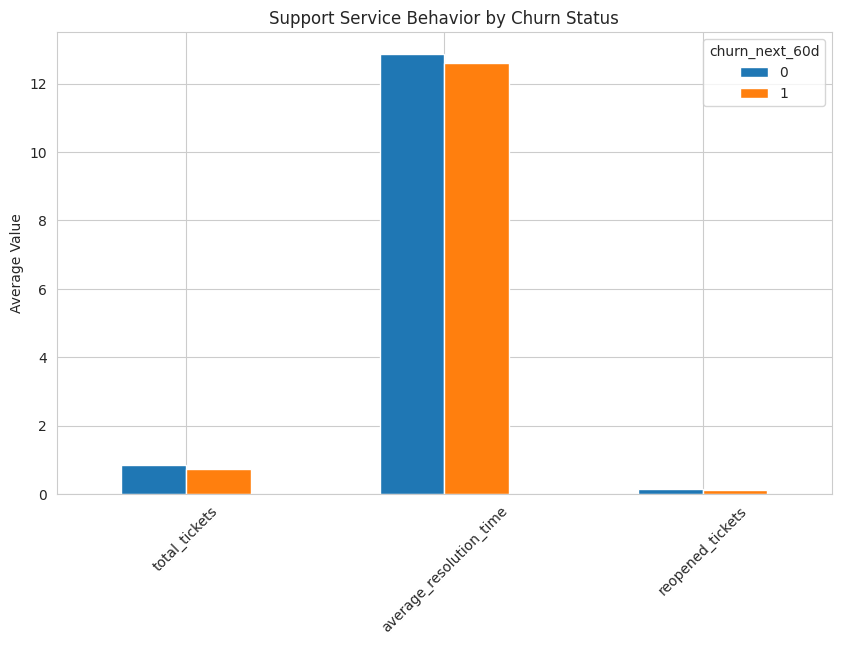

In [ ]:
ticket_churn_analysis = (
    customer_analysis
    .groupby("churn_next_60d")
    [
        [
            "total_tickets",
            "average_resolution_time",
            "reopened_tickets"
        ]
    ]
    .mean()
)

display(ticket_churn_analysis)

ticket_churn_analysis.T.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Support Service Behavior by Churn Status"
)

plt.ylabel("Average Value")
plt.xticks(rotation=45)

plt.show()

**Chart 9: Return Behavior and Churn Analysis**


Customers returning more products may experience dissatisfaction and demonstrate elevated future churn probability.

,total_returns,average_rating,average_delivery_days
churn_next_60d,,,
0,0.23,3.92,4.47
1,0.22,3.86,4.45


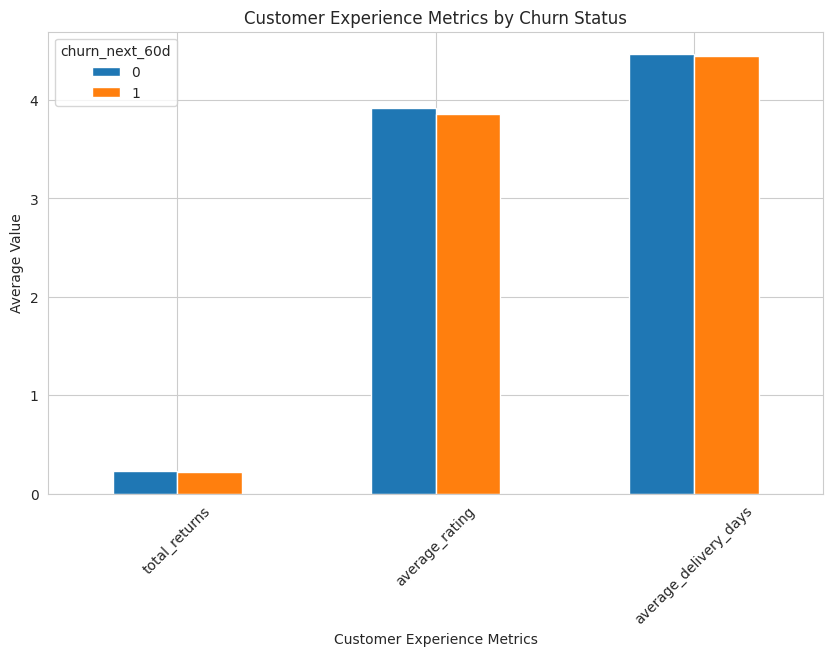

In [ ]:
return_analysis = (
    customer_analysis
    .groupby("churn_next_60d")[
        [
            "total_returns",
            "average_rating",
            "average_delivery_days"
        ]
    ]
    .mean()
    .round(2)
)

display(return_analysis)

return_analysis.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Customer Experience Metrics by Churn Status"
)

plt.xlabel("Customer Experience Metrics")
plt.ylabel("Average Value")

plt.xticks(rotation=45)

plt.show()

**Chart 10: Campaign History and Churn Relationship**


Previous retention campaigns should be evaluated to understand whether interventions reduce customer churn.

,churn_next_60d
last_campaign_received,
new_launch,51.00
bundle_discount,46.93
free_shipping,46.27
welcome_offer,45.25
none,45.17


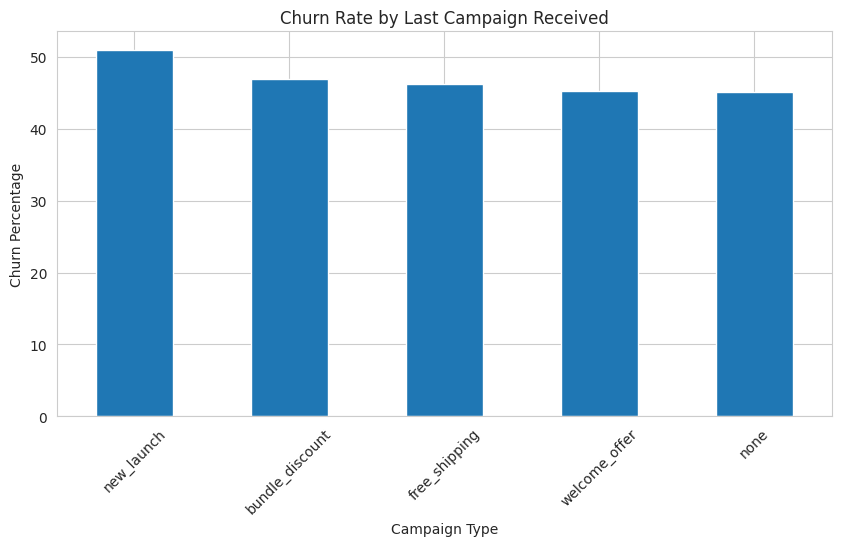

In [ ]:
campaign_churn = (
    customer_analysis
    .groupby("last_campaign_received")[
        "churn_next_60d"
    ]
    .mean()
    .sort_values(
        ascending=False
    )
    .mul(100)
    .round(2)
)

display(campaign_churn)

plt.figure(figsize=(10, 5))

campaign_churn.plot(
    kind="bar"
)

plt.title(
    "Churn Rate by Last Campaign Received"
)

plt.xlabel("Campaign Type")
plt.ylabel("Churn Percentage")

plt.xticks(rotation=45)

plt.show()

**Chart 11: Marketing Consent and Churn Comparison**


Communication permissions may influence customer engagement opportunities and future retention effectiveness.

,churn_next_60d
marketing_consent,
No,47.97
Yes,46.59


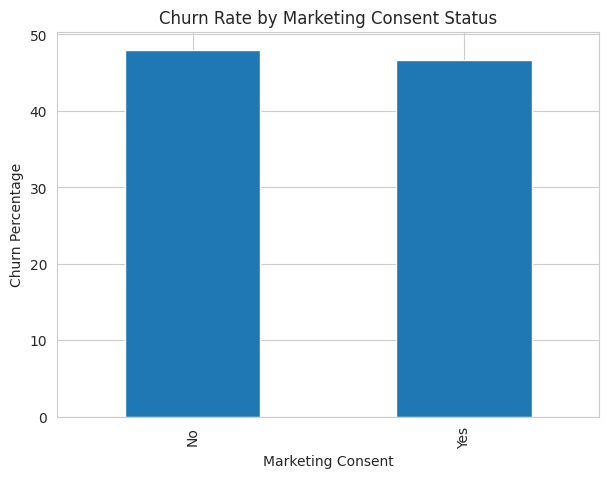

In [ ]:
marketing_churn = (
    customer_analysis
    .groupby("marketing_consent")[
        "churn_next_60d"
    ]
    .mean()
    .mul(100)
    .round(2)
)

display(marketing_churn)

plt.figure(figsize=(7, 5))

marketing_churn.plot(
    kind="bar"
)

plt.title(
    "Churn Rate by Marketing Consent Status"
)

plt.xlabel("Marketing Consent")
plt.ylabel("Churn Percentage")

plt.show()

**Section 20: Create Churn Risk Segments for Customer-Level Evidence**

Customer segments help identify individuals requiring deeper business investigation before retention investments.

In [ ]:
high_risk_customers = customer_analysis[
    customer_analysis["churn_next_60d"] == 1
]

high_risk_sample = (
    high_risk_customers[
        [
            "customer_id",
            "city_tier",
            "acquisition_channel",
            "total_orders",
            "total_spend",
            "total_tickets",
            "average_sentiment",
            "sessions_30d",
            "last_campaign_received"
        ]
    ]
    .sort_values(
        by=[
            "total_spend",
            "sessions_30d"
        ]
    )
    .head(10)
)

display(high_risk_sample)

,customer_id,city_tier,acquisition_channel,total_orders,total_spend,total_tickets,average_sentiment,sessions_30d,last_campaign_received
1656,CUST01657,Tier 2,Google Search,1,149.00,0.0,0.00,2,new_launch
1175,CUST01176,Tier 1,Organic,1,149.00,0.0,0.00,6,none
1747,CUST01748,Tier 3,Google Search,1,150.03,0.0,0.00,4,new_launch
601,CUST00602,Tier 3,Influencer,1,171.18,0.0,0.00,5,new_launch
206,CUST00207,Tier 1,Influencer,1,193.10,0.0,0.00,11,none
1261,CUST01262,Tier 1,Influencer,1,195.09,0.0,0.00,11,welcome_offer
238,CUST00239,Tier 1,Instagram,1,208.10,0.0,0.00,4,bundle_discount
2234,CUST02235,Tier 2,Referral,1,221.66,0.0,0.00,1,free_shipping
1337,CUST01338,Tier 3,Organic,1,232.88,1.0,-0.74,14,bundle_discount
1019,CUST01020,Tier 1,Referral,1,236.73,0.0,0.00,1,new_launch


# Section 21: Five Data-Backed Churn Risk Hypotheses


Business hypotheses transform analytical findings into actionable investigations before launching expensive retention campaigns.

In [ ]:
churn_hypotheses = pd.DataFrame({
    "Hypothesis": [
        "Customers with lower purchase frequency are more likely to churn.",
        "Customers showing reduced web engagement have higher churn risk.",
        "Customers experiencing multiple support issues show elevated churn.",
        "Customers with higher returns and poor ratings churn more often.",
        "Certain acquisition channels generate lower customer loyalty."
    ],

    "Supporting_Evidence": [
        "Order frequency comparison and spending distribution charts.",
        "Sessions, product views, and campaign click analysis.",
        "Support ticket volume, resolution time, and reopen analysis.",
        "Return counts, ratings, and delivery experience comparison.",
        "Acquisition channel churn-rate comparison."
    ],

    "Business_Action": [
        "Create reactivation journeys for declining buyers.",
        "Launch personalized recommendations for inactive visitors.",
        "Improve support quality and reduce complaint resolution delays.",
        "Investigate product quality and fulfillment experience.",
        "Optimize marketing spend toward higher-retention channels."
    ]
})

display(churn_hypotheses)

,Hypothesis,Supporting_Evidence,Business_Action
0,Customers with lower purchase frequency are mo...,Order frequency comparison and spending distri...,Create reactivation journeys for declining buy...
1,Customers showing reduced web engagement have ...,"Sessions, product views, and campaign click an...",Launch personalized recommendations for inacti...
2,Customers experiencing multiple support issues...,"Support ticket volume, resolution time, and re...",Improve support quality and reduce complaint r...
3,Customers with higher returns and poor ratings...,"Return counts, ratings, and delivery experienc...",Investigate product quality and fulfillment ex...
4,Certain acquisition channels generate lower cu...,Acquisition channel churn-rate comparison.,Optimize marketing spend toward higher-retenti...


**Section 22: Save Important EDA Outputs**


Saving analytical outputs improves reproducibility and provides evidence for business stakeholders and evaluators.

In [ ]:
churn_hypotheses.to_csv(
    "churn_risk_hypotheses.csv",
    index=False
)

high_risk_sample.to_csv(
    "high_risk_customer_examples.csv",
    index=False
)

print(
    "EDA evidence files successfully saved."
)

EDA evidence files successfully saved.
